# ✈️ Airline Passenger Satisfaction — EDA & Root Cause Analysis
> **Goal:** Identify structural root causes behind low satisfaction using segment analysis, service rating deep-dives, correlation analysis, and a 5-Why RCA framework.

---
## Table of Contents
1. [Setup & Data Loading](#1-setup)
2. [Dataset Overview](#2-overview)
3. [Target Variable](#3-target)
4. [Segment Profiles](#4-segments)
5. [Operational Metrics](#5-operations)
6. [Service Ratings](#6-service-ratings)
7. [Correlation Analysis](#7-correlation)
8. [Segment Deep-Dives](#8-deep-dives)
9. [RCA Summary](#9-rca)
10. [Findings & Recommendations](#10-findings)


---
## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from matplotlib.backends.backend_pdf import PdfPages
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# ── Output PDF setup ──────────────────────────────────────────────────────────
PDF_PATH = 'airline_satisfaction_eda_figures.pdf'
pdf_pages = PdfPages(PDF_PATH)

def save_fig(fig, png_name):
    """Save figure to both the multi-page PDF and a named PNG."""
    pdf_pages.savefig(fig, bbox_inches='tight')
    fig.savefig(png_name, dpi=150, bbox_inches='tight')

# ── Colour palette ───────────────────────────────────────────────────────────
SAT_COLORS = {'Satisfied': '#2a78d6', 'Neutral or Dissatisfied': '#e24b4a'}
CLASS_PAL  = {'Business': '#2a78d6', 'Economy Plus': '#eda100', 'Economy': '#e24b4a'}
BLUE, RED, AMBER, GRAY = '#2a78d6', '#e24b4a', '#eda100', '#888780'

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e1e0d9', 'grid.linewidth': 0.5,
    'font.size': 11, 'axes.titlesize': 13, 'axes.titleweight': 'bold',
})

# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv('Airline_satisfaction.csv')
df['sat_binary'] = (df['Satisfaction'] == 'Satisfied').astype(int)
df['age_group']  = pd.cut(df['Age'], bins=[0,18,25,35,45,55,65,100],
                           labels=['<18','18-25','26-35','36-45','46-55','56-65','65+'])

# ── Normalise Customer Type labels (raw data uses 'Loyal'/'disloyal') ─────────
if 'Loyal Customer' in df['Customer Type'].unique():
    df['Customer Type'] = df['Customer Type'].replace({
        'Loyal Customer': 'Returning',
        'disloyal Customer': 'First-time'
    })

SERVICE_COLS = [
    'Online Boarding', 'In-flight Wifi Service', 'In-flight Entertainment',
    'Seat Comfort', 'On-board Service', 'Leg Room Service', 'Cleanliness',
    'Food and Drink', 'Check-in Service', 'Baggage Handling',
    'In-flight Service', 'Ease of Online Booking',
    'Gate Location', 'Departure and Arrival Time Convenience'
]

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nSatisfaction split:\n{df['Satisfaction'].value_counts()}")
print(f"\nCustomer Type values: {df['Customer Type'].unique().tolist()}")


Shape: (129880, 26)
Columns: ['ID', 'Gender', 'Age', 'Customer Type', 'Type of Travel', 'Class', 'Flight Distance', 'Departure Delay', 'Arrival Delay', 'Departure and Arrival Time Convenience', 'Ease of Online Booking', 'Check-in Service', 'Online Boarding', 'Gate Location', 'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness', 'Food and Drink', 'In-flight Service', 'In-flight Wifi Service', 'In-flight Entertainment', 'Baggage Handling', 'Satisfaction', 'sat_binary', 'age_group']

Satisfaction split:
Satisfaction
Neutral or Dissatisfied    73452
Satisfied                  56428
Name: count, dtype: int64

Customer Type values: ['First-time', 'Returning']


---
## 2. Dataset Overview

In [2]:
# Descriptive statistics
display(df.describe().T.round(2))


,count,mean,std,min,25%,50%,75%,max
ID,129880.0,64940.50,37493.27,1.0,32470.75,64940.5,97410.25,129880.0
Age,129880.0,39.43,15.12,7.0,27.00,40.0,51.00,85.0
Flight Distance,129880.0,1190.32,997.45,31.0,414.00,844.0,1744.00,4983.0
Departure Delay,129880.0,14.71,38.07,0.0,0.00,0.0,12.00,1592.0
Arrival Delay,129880.0,15.05,38.42,0.0,0.00,0.0,13.00,1584.0
Departure and Arrival Time Convenience,129880.0,3.06,1.53,0.0,2.00,3.0,4.00,5.0
Ease of Online Booking,129880.0,2.76,1.40,0.0,2.00,3.0,4.00,5.0
Check-in Service,129880.0,3.31,1.27,0.0,3.00,3.0,4.00,5.0
Online Boarding,129880.0,3.25,1.35,0.0,2.00,3.0,4.00,5.0
Gate Location,129880.0,2.98,1.28,0.0,2.00,3.0,4.00,5.0


In [3]:
# Data quality check
print("=== Missing values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "None — clean dataset ✓")

print("\n=== Categorical values ===")
for c in ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'Satisfaction']:
    print(f"  {c}: {df[c].unique().tolist()}")

print(f"\n=== Age range: {df['Age'].min()} – {df['Age'].max()} years ===")
print(f"=== Flight distance: {df['Flight Distance'].min()} – {df['Flight Distance'].max()} miles ===")


=== Missing values ===
None — clean dataset ✓

=== Categorical values ===
  Gender: ['Male', 'Female']
  Customer Type: ['First-time', 'Returning']
  Type of Travel: ['Business', 'Personal']
  Class: ['Business', 'Economy', 'Economy Plus']
  Satisfaction: ['Neutral or Dissatisfied', 'Satisfied']

=== Age range: 7 – 85 years ===
=== Flight distance: 31 – 4983 miles ===


---
## 3. Target Variable

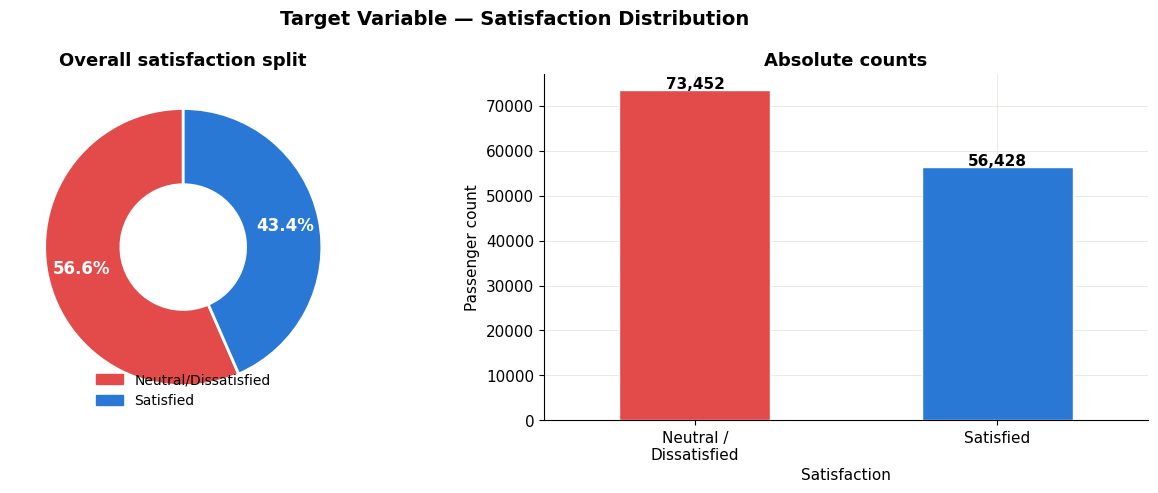


Satisfied: 56,428 (43.4%)
Dissatisfied: 73,452 (56.6%)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Target Variable — Satisfaction Distribution', fontsize=14, fontweight='bold')

vals = df['Satisfaction'].value_counts()
colors = [SAT_COLORS[v] for v in vals.index]

# Donut chart
ax = axes[0]
wedges, _, autotexts = ax.pie(vals, autopct='%1.1f%%', colors=colors,
    startangle=90, pctdistance=0.75, wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2))
for at in autotexts:
    at.set_fontsize(12); at.set_fontweight('bold'); at.set_color('white')
ax.legend([mpatches.Patch(color=c) for c in colors],
          [v.replace('Neutral or Dissatisfied', 'Neutral/Dissatisfied') for v in vals.index],
          loc='lower center', fontsize=10, frameon=False)
ax.set_title('Overall satisfaction split')

# Count bar
ax = axes[1]
vals.plot(kind='bar', ax=ax, color=colors, edgecolor='white', width=0.5)
ax.set_xticklabels(['Neutral /\nDissatisfied', 'Satisfied'], rotation=0)
ax.set_ylabel('Passenger count')
ax.set_title('Absolute counts')
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 300,
            f'{int(p.get_height()):,}', ha='center', fontsize=11, fontweight='bold')
ax.yaxis.grid(True); ax.set_axisbelow(True)

plt.tight_layout()
save_fig(fig, 'fig_01_satisfaction_distribution.png')
plt.show()

sat_rate = df['sat_binary'].mean() * 100
print(f"\nSatisfied: {vals.get('Satisfied', 0):,} ({sat_rate:.1f}%)")
print(f"Dissatisfied: {vals.get('Neutral or Dissatisfied', 0):,} ({100-sat_rate:.1f}%)")


---
## 4. Segment Profiles

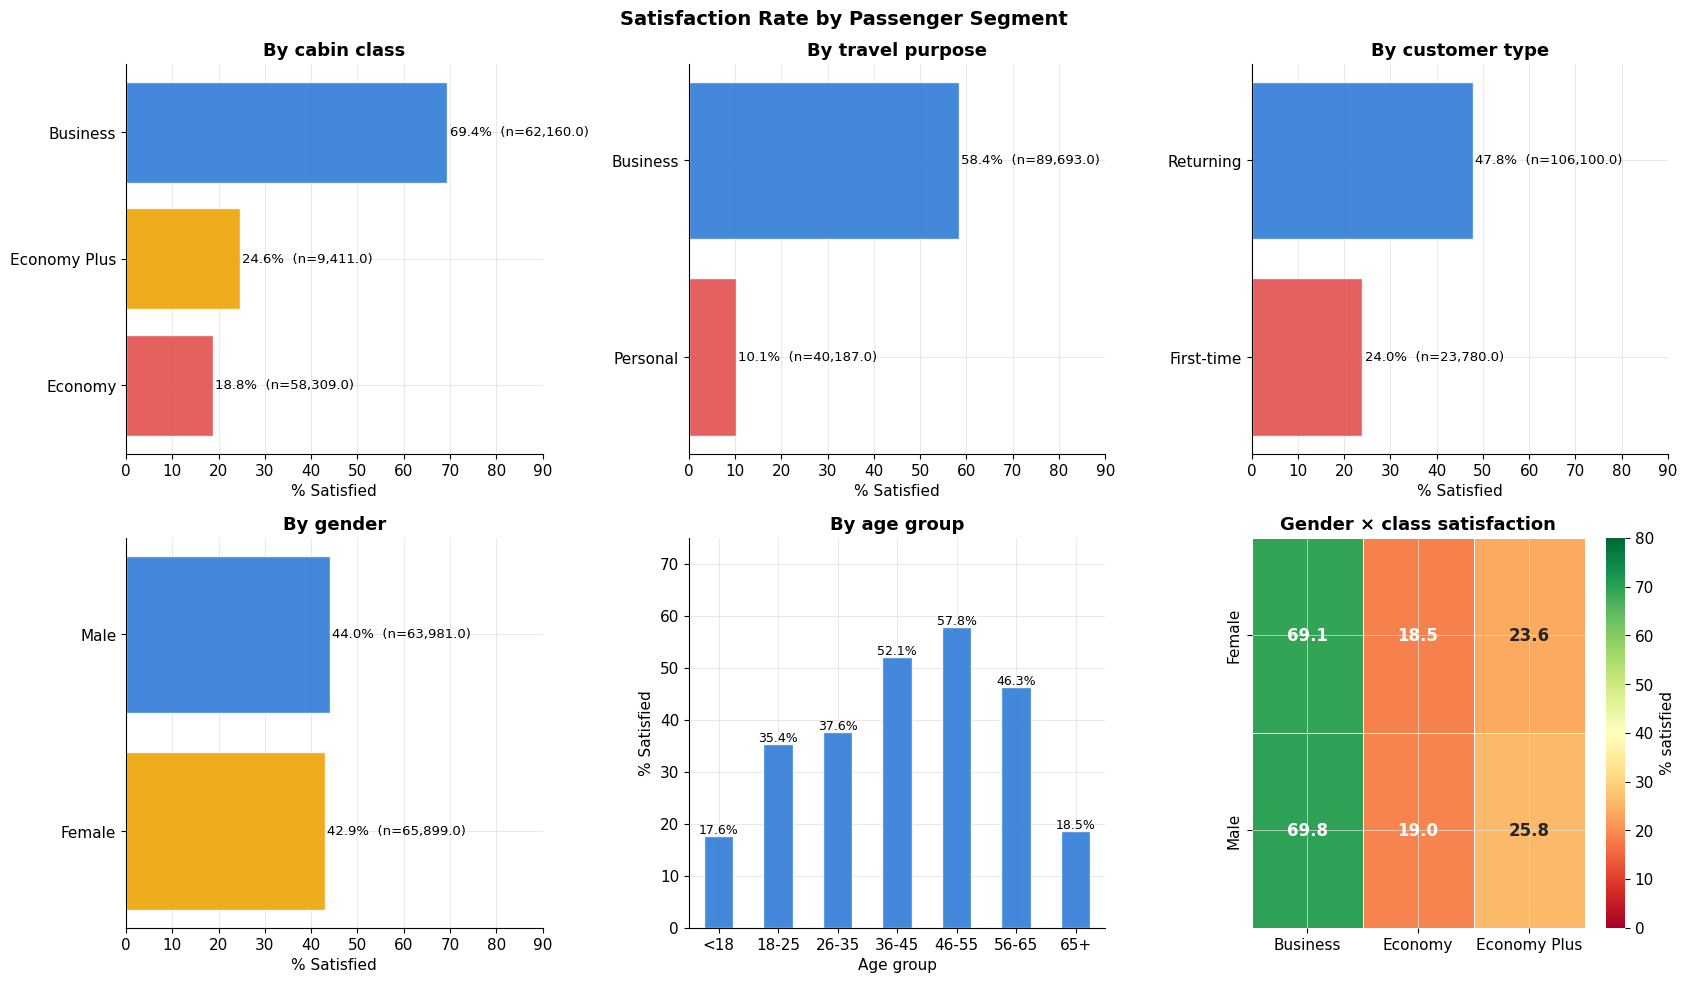

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Satisfaction Rate by Passenger Segment', fontsize=14, fontweight='bold')

def sat_bar_h(ax, col, palette=None, title=''):
    grp = df.groupby(col)['sat_binary'].agg(['mean','count'])
    grp['pct'] = grp['mean'] * 100
    grp = grp.sort_values('pct')
    colors = [palette.get(i, BLUE) for i in grp.index] if palette else [BLUE]*len(grp)
    ax.barh(grp.index.astype(str), grp['pct'], color=colors, edgecolor='white', alpha=0.88)
    for i, (idx, row) in enumerate(grp.iterrows()):
        ax.text(row['pct'] + 0.5, i, f"{row['pct']:.1f}%  (n={row['count']:,})",
                va='center', fontsize=9.5)
    ax.set_xlabel('% Satisfied')
    ax.set_title(title)
    ax.set_xlim(0, 90)
    ax.xaxis.grid(True); ax.set_axisbelow(True)

sat_bar_h(axes[0,0], 'Class',          CLASS_PAL,  'By cabin class')
sat_bar_h(axes[0,1], 'Type of Travel', {'Business': BLUE, 'Personal': RED}, 'By travel purpose')
sat_bar_h(axes[0,2], 'Customer Type',  {'Returning': BLUE, 'First-time': RED}, 'By customer type')
sat_bar_h(axes[1,0], 'Gender',         {'Male': BLUE, 'Female': AMBER}, 'By gender')

# Age group bar
ax = axes[1,1]
ag = df.groupby('age_group', observed=True)['sat_binary'].mean() * 100
ag.plot(kind='bar', ax=ax, color=BLUE, edgecolor='white', alpha=0.88)
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 0.5,
            f'{p.get_height():.1f}%', ha='center', fontsize=9)
ax.set_xticklabels(ag.index, rotation=0)
ax.set_xlabel('Age group'); ax.set_ylabel('% Satisfied')
ax.set_title('By age group'); ax.set_ylim(0, 75)
ax.yaxis.grid(True); ax.set_axisbelow(True)

# Gender × class heatmap
ax = axes[1,2]
pivot_gc = df.groupby(['Gender', 'Class'])['sat_binary'].mean().unstack() * 100
sns.heatmap(pivot_gc, ax=ax, annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=0, vmax=80, linewidths=0.5, annot_kws={'size': 12, 'weight': 'bold'},
            cbar_kws={'label': '% satisfied'})
ax.set_title('Gender × class satisfaction')
ax.set_xlabel(''); ax.set_ylabel('')

plt.tight_layout()
save_fig(fig, 'fig_02_segment_profiles.png')
plt.show()


In [6]:
# Detailed satisfaction rates
print("=== Satisfaction rate by segment ===")
for col in ['Class', 'Type of Travel', 'Customer Type', 'Gender']:
    tbl = df.groupby(col)['sat_binary'].agg(['mean','count'])
    tbl.columns = ['% Satisfied', 'Count']
    tbl['% Satisfied'] = (tbl['% Satisfied']*100).round(1)
    print(f"\n── {col} ──")
    print(tbl.sort_values('% Satisfied', ascending=False).to_string())


=== Satisfaction rate by segment ===

── Class ──
              % Satisfied  Count
Class                           
Business             69.4  62160
Economy Plus         24.6   9411
Economy              18.8  58309

── Type of Travel ──
                % Satisfied  Count
Type of Travel                    
Business               58.4  89693
Personal               10.1  40187

── Customer Type ──
               % Satisfied   Count
Customer Type                     
Returning             47.8  106100
First-time            24.0   23780

── Gender ──
        % Satisfied  Count
Gender                    
Male           44.0  63981
Female         42.9  65899


---
## 5. Operational Metrics — Delays & Flight Distance

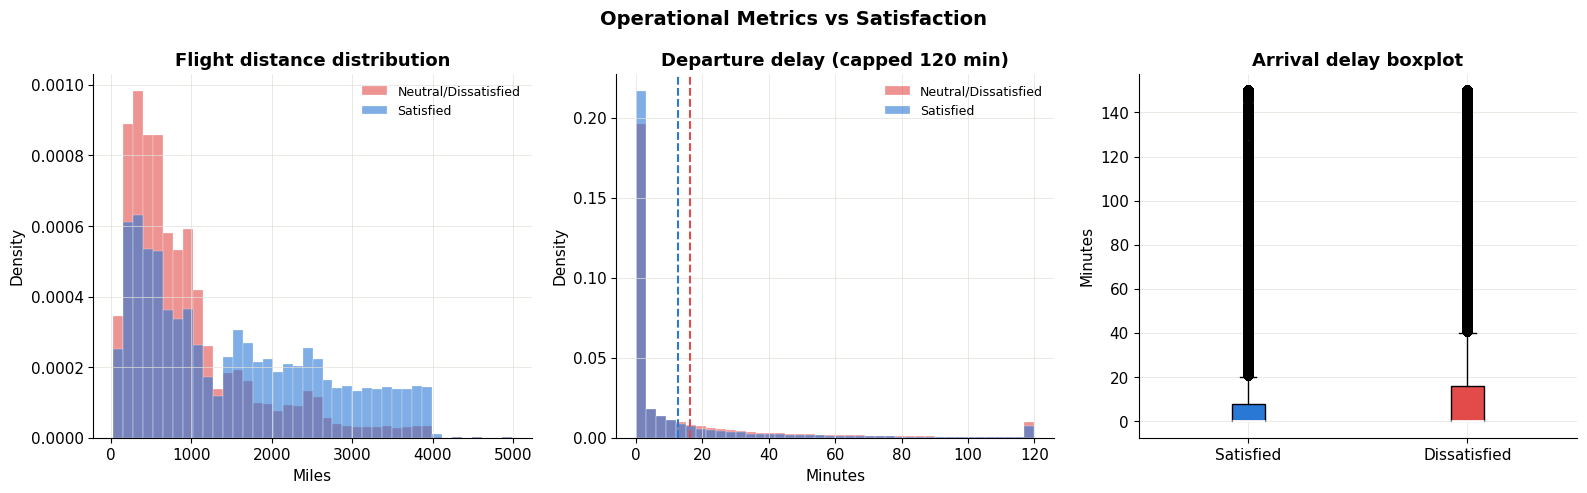

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Operational Metrics vs Satisfaction', fontsize=14, fontweight='bold')

# Flight distance
ax = axes[0]
for sat, grp in df.groupby('Satisfaction'):
    ax.hist(grp['Flight Distance'], bins=40, alpha=0.6, color=SAT_COLORS[sat],
            label=sat.replace('Neutral or Dissatisfied','Neutral/Dissatisfied'),
            density=True, edgecolor='white', linewidth=0.3)
ax.set_title('Flight distance distribution')
ax.set_xlabel('Miles'); ax.set_ylabel('Density')
ax.legend(fontsize=9, frameon=False)

# Departure delay (capped)
ax = axes[1]
for sat, grp in df.groupby('Satisfaction'):
    data = grp['Departure Delay'].clip(upper=120)
    ax.hist(data, bins=40, alpha=0.6, color=SAT_COLORS[sat], density=True,
            edgecolor='white', linewidth=0.3,
            label=sat.replace('Neutral or Dissatisfied','Neutral/Dissatisfied'))
ax.set_title('Departure delay (capped 120 min)')
ax.set_xlabel('Minutes'); ax.set_ylabel('Density')
for sat, grp in df.groupby('Satisfaction'):
    m = grp['Departure Delay'].mean()
    ax.axvline(m, color=SAT_COLORS[sat], linestyle='--', linewidth=1.5)
ax.legend(fontsize=9, frameon=False)

# Arrival delay boxplot
ax = axes[2]
data_s = df[df['Satisfaction']=='Satisfied']['Arrival Delay'].clip(upper=150)
data_d = df[df['Satisfaction']!='Satisfied']['Arrival Delay'].clip(upper=150)
bp = ax.boxplot([data_s, data_d], patch_artist=True,
                medianprops=dict(color='white', linewidth=2),
                whiskerprops=dict(linewidth=1), capprops=dict(linewidth=1))
bp['boxes'][0].set_facecolor(BLUE)
bp['boxes'][1].set_facecolor(RED)
ax.set_xticklabels(['Satisfied', 'Dissatisfied'])
ax.set_title('Arrival delay boxplot')
ax.set_ylabel('Minutes')

plt.tight_layout()
save_fig(fig, 'fig_03_operational_metrics.png')
plt.show()


In [8]:
# Statistical test: is delay difference significant?
sat_d = df[df['Satisfaction']=='Satisfied']['Departure Delay']
dis_d = df[df['Satisfaction']!='Satisfied']['Departure Delay']
u, p  = stats.mannwhitneyu(sat_d, dis_d, alternative='two-sided')

print("=== Departure Delay — Mann-Whitney U Test ===")
print(f"  Satisfied mean:      {sat_d.mean():.1f} min")
print(f"  Dissatisfied mean:   {dis_d.mean():.1f} min")
print(f"  Difference:          {dis_d.mean()-sat_d.mean():.1f} min")
print(f"  U-statistic:         {u:.0f}")
print(f"  p-value:             {p:.6f}")
print(f"  Verdict: {'Significant (p<0.05) — but small effect' if p<0.05 else 'Not significant'}")
print("\n  Conclusion: Delays are an AMPLIFIER, not a root cause (~4 min gap)")


=== Departure Delay — Mann-Whitney U Test ===
  Satisfied mean:      12.5 min
  Dissatisfied mean:   16.4 min
  Difference:          3.9 min
  U-statistic:         1921723072
  p-value:             0.000000
  Verdict: Significant (p<0.05) — but small effect

  Conclusion: Delays are an AMPLIFIER, not a root cause (~4 min gap)


---
## 6. Service Ratings Deep-Dive

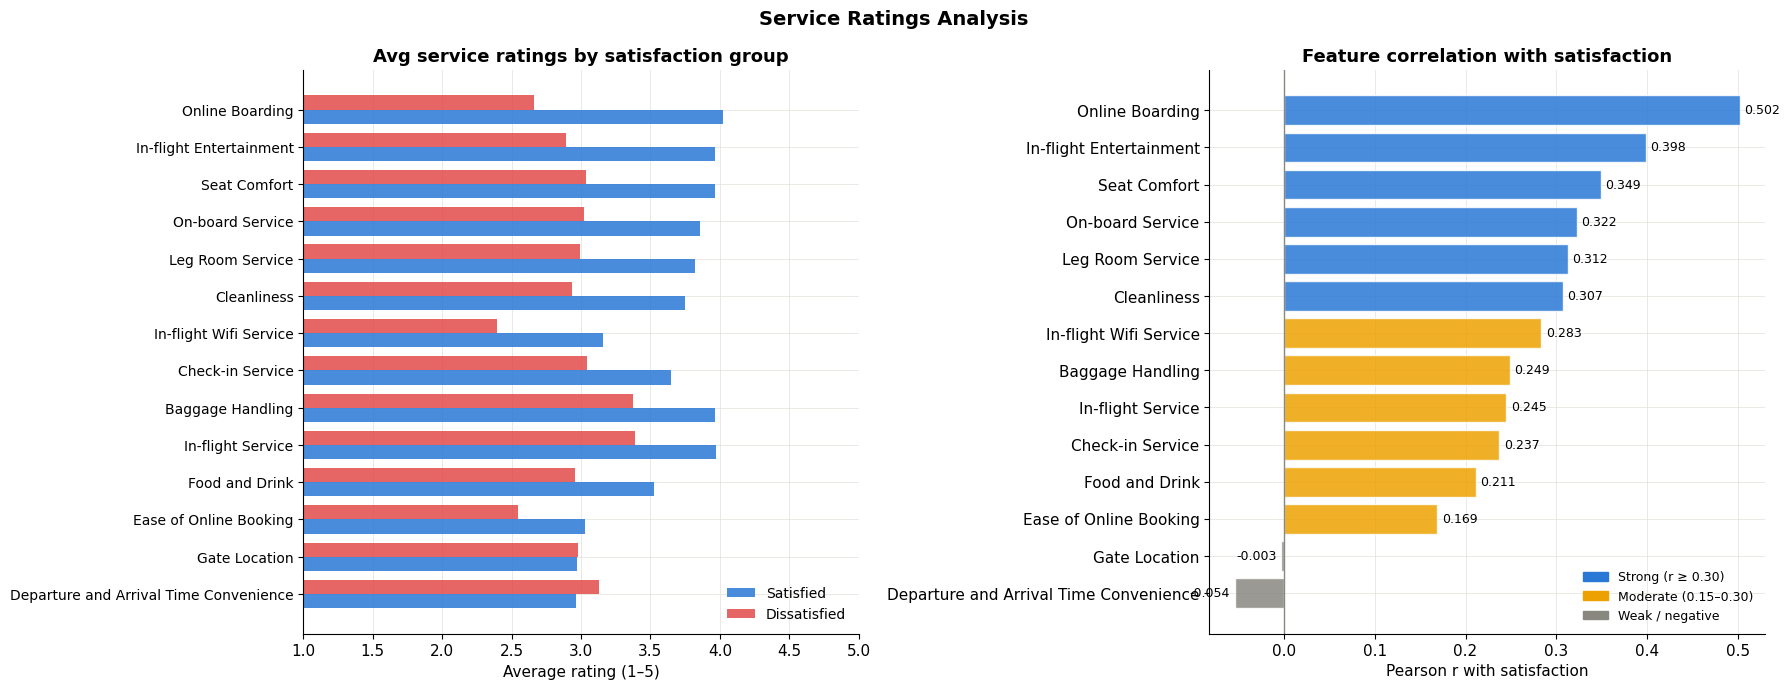

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Service Ratings Analysis', fontsize=14, fontweight='bold')

# Avg rating: satisfied vs dissatisfied
ax = axes[0]
avg = df.groupby('Satisfaction')[SERVICE_COLS].mean().T
avg['gap'] = avg['Satisfied'] - avg['Neutral or Dissatisfied']
avg = avg.sort_values('gap')
x = np.arange(len(avg))
w = 0.38
ax.barh(x - w/2, avg['Satisfied'], w, color=BLUE, label='Satisfied', alpha=0.85)
ax.barh(x + w/2, avg['Neutral or Dissatisfied'], w, color=RED, label='Dissatisfied', alpha=0.85)
ax.set_yticks(x); ax.set_yticklabels(avg.index, fontsize=10)
ax.set_xlabel('Average rating (1–5)')
ax.set_title('Avg service ratings by satisfaction group')
ax.legend(fontsize=10, frameon=False)
ax.set_xlim(1, 5)
ax.xaxis.grid(True); ax.set_axisbelow(True)

# Pearson correlation (computed, not hardcoded)
ax = axes[1]
corr = df[SERVICE_COLS + ['sat_binary']].corr()['sat_binary'].drop('sat_binary').sort_values()
bar_colors = [BLUE if v>=0.3 else AMBER if v>=0.15 else GRAY for v in corr]
bars = ax.barh(corr.index, corr.values, color=bar_colors, alpha=0.85, edgecolor='white')
ax.axvline(0, color=GRAY, linewidth=1)
ax.set_xlabel('Pearson r with satisfaction')
ax.set_title('Feature correlation with satisfaction')
for bar, val in zip(bars, corr.values):
    xp = val + 0.005 if val >= 0 else val - 0.005
    ax.text(xp, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
            va='center', ha='left' if val>=0 else 'right', fontsize=9)
ax.legend(handles=[
    mpatches.Patch(color=BLUE,  label='Strong (r ≥ 0.30)'),
    mpatches.Patch(color=AMBER, label='Moderate (0.15–0.30)'),
    mpatches.Patch(color=GRAY,  label='Weak / negative'),
], fontsize=9, frameon=False, loc='lower right')
ax.xaxis.grid(True); ax.set_axisbelow(True)

plt.tight_layout()
save_fig(fig, 'fig_04_service_ratings.png')
plt.show()


In [10]:
# Rating gap table
avg = df.groupby('Satisfaction')[SERVICE_COLS].mean().T
avg.columns = ['Dissatisfied_avg', 'Satisfied_avg']
avg['Rating_gap'] = avg['Satisfied_avg'] - avg['Dissatisfied_avg']
avg['Correlation_r'] = df[SERVICE_COLS + ['sat_binary']].corr()['sat_binary'].drop('sat_binary')

# % low ratings among dissatisfied
dis = df[df['Satisfaction']=='Neutral or Dissatisfied']
avg['Low_rating_pct_dissatisfied'] = (dis[SERVICE_COLS] <= 2).mean() * 100

print("=== Service Rating Summary ===")
display(avg.sort_values('Correlation_r', ascending=False).round(3))


=== Service Rating Summary ===


,Dissatisfied_avg,Satisfied_avg,Rating_gap,Correlation_r,Low_rating_pct_dissatisfied
Online Boarding,2.659,4.026,1.367,0.502,43.834
In-flight Entertainment,2.892,3.964,1.072,0.398,41.883
Seat Comfort,3.038,3.966,0.928,0.349,35.501
On-board Service,3.020,3.856,0.837,0.322,34.781
Leg Room Service,2.990,3.820,0.830,0.312,38.719
Cleanliness,2.933,3.747,0.814,0.307,39.868
In-flight Wifi Service,2.398,3.159,0.760,0.283,53.559
Baggage Handling,3.375,3.967,0.592,0.249,22.402
In-flight Service,3.390,3.971,0.581,0.245,22.167
Check-in Service,3.043,3.649,0.606,0.237,33.099


---
## 7. Correlation Analysis

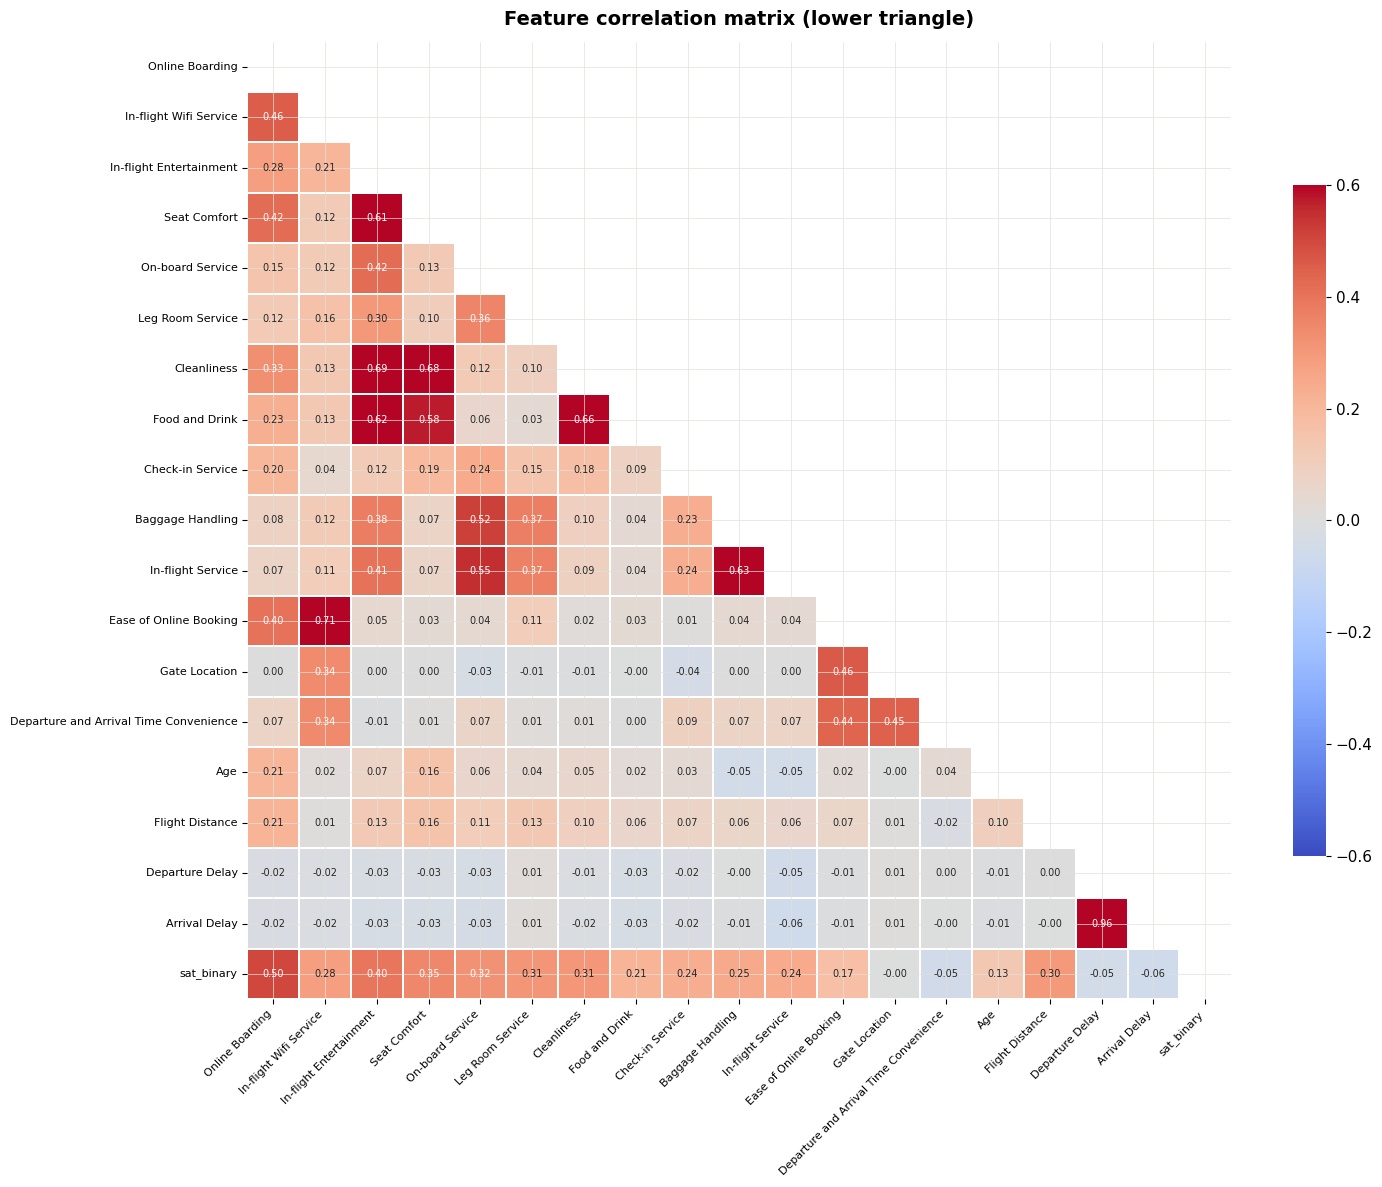

In [11]:
fig, ax = plt.subplots(figsize=(15, 12))
num_cols = SERVICE_COLS + ['Age', 'Flight Distance', 'Departure Delay', 'Arrival Delay', 'sat_binary']
corr_m   = df[num_cols].corr()
mask     = np.triu(np.ones_like(corr_m, dtype=bool))  # mask upper triangle, show lower
sns.heatmap(corr_m, ax=ax, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-0.6, vmax=0.6,
            linewidths=0.3, cbar_kws={'shrink': 0.7},
            annot_kws={'size': 7})
ax.set_title('Feature correlation matrix (lower triangle)', fontsize=14, fontweight='bold', pad=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
save_fig(fig, 'fig_05_correlation_matrix.png')
plt.show()


In [12]:
# Flag highly correlated pairs (multicollinearity check)
num_cols = SERVICE_COLS + ['Age', 'Flight Distance', 'Departure Delay', 'Arrival Delay']
corr_m = df[num_cols].corr()
pairs = []
for i in range(len(corr_m.columns)):
    for j in range(i+1, len(corr_m.columns)):
        pairs.append((corr_m.columns[i], corr_m.columns[j], corr_m.iloc[i,j]))
pairs_df = pd.DataFrame(pairs, columns=['Feature A','Feature B','r']).sort_values('r', ascending=False)

print("Top 10 correlated pairs:")
display(pairs_df.head(10).round(3))
print("\nHighly correlated (|r| > 0.6) — watch for multicollinearity in models:")
display(pairs_df[pairs_df['r'].abs()>0.6].round(3))


Top 10 correlated pairs:


,Feature A,Feature B,r
152,Departure Delay,Arrival Delay,0.959
26,In-flight Wifi Service,Ease of Online Booking,0.715
36,In-flight Entertainment,Cleanliness,0.693
50,Seat Comfort,Cleanliness,0.680
87,Cleanliness,Food and Drink,0.658
117,Baggage Handling,In-flight Service,0.629
37,In-flight Entertainment,Food and Drink,0.623
33,In-flight Entertainment,Seat Comfort,0.612
51,Seat Comfort,Food and Drink,0.576
67,On-board Service,In-flight Service,0.552



Highly correlated (|r| > 0.6) — watch for multicollinearity in models:


,Feature A,Feature B,r
152,Departure Delay,Arrival Delay,0.959
26,In-flight Wifi Service,Ease of Online Booking,0.715
36,In-flight Entertainment,Cleanliness,0.693
50,Seat Comfort,Cleanliness,0.680
87,Cleanliness,Food and Drink,0.658
117,Baggage Handling,In-flight Service,0.629
37,In-flight Entertainment,Food and Drink,0.623
33,In-flight Entertainment,Seat Comfort,0.612


---
## 8. Segment Deep-Dives

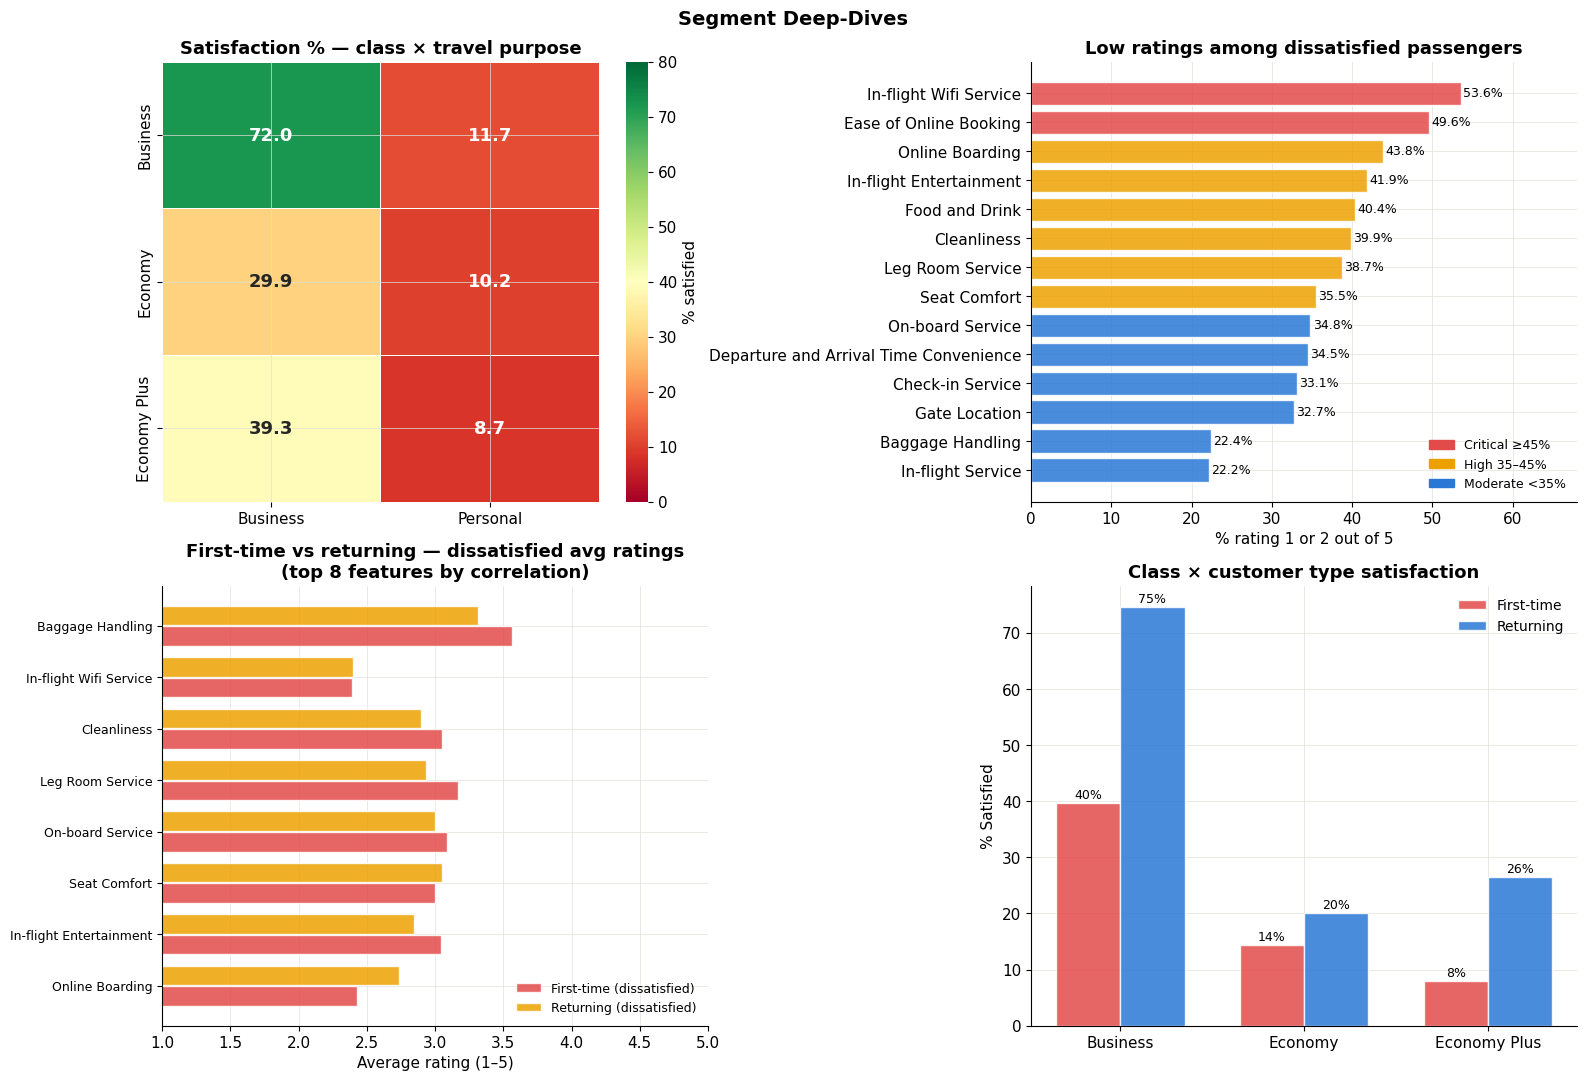

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Segment Deep-Dives', fontsize=14, fontweight='bold')

# 8a — Class × Travel type heatmap
ax = axes[0,0]
pivot = df.groupby(['Class','Type of Travel'])['sat_binary'].mean().unstack() * 100
sns.heatmap(pivot, ax=ax, annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=0, vmax=80, linewidths=0.5,
            cbar_kws={'label': '% satisfied'}, annot_kws={'size': 13, 'weight': 'bold'})
ax.set_title('Satisfaction % — class × travel purpose')
ax.set_xlabel(''); ax.set_ylabel('')

# 8b — % low ratings (1-2) among dissatisfied
ax = axes[0,1]
dis = df[df['Satisfaction']=='Neutral or Dissatisfied']
low_pct = (dis[SERVICE_COLS] <= 2).mean().sort_values() * 100
bar_c = [RED if v>=45 else AMBER if v>=35 else BLUE for v in low_pct]
ax.barh(low_pct.index, low_pct.values, color=bar_c, alpha=0.85, edgecolor='white')
for i, v in enumerate(low_pct.values):
    ax.text(v+0.3, i, f'{v:.1f}%', va='center', fontsize=9)
ax.set_xlabel('% rating 1 or 2 out of 5')
ax.set_title('Low ratings among dissatisfied passengers')
ax.set_xlim(0, 68)
ax.legend(handles=[
    mpatches.Patch(color=RED,   label='Critical ≥45%'),
    mpatches.Patch(color=AMBER, label='High 35–45%'),
    mpatches.Patch(color=BLUE,  label='Moderate <35%'),
], fontsize=9, frameon=False)
ax.xaxis.grid(True); ax.set_axisbelow(True)

# 8c — First-time vs returning (dissatisfied avg rating)
# Top 8 service features by correlation (computed, not hardcoded)
corr_vals = df[SERVICE_COLS + ['sat_binary']].corr()['sat_binary'].drop('sat_binary')
top8_by_corr = corr_vals.nlargest(8).index.tolist()

ax = axes[1,0]
ft_dis = df[(df['Customer Type']=='First-time') & (df['Satisfaction']!='Satisfied')][top8_by_corr].mean()
rt_dis = df[(df['Customer Type']=='Returning')  & (df['Satisfaction']!='Satisfied')][top8_by_corr].mean()
x = np.arange(len(top8_by_corr))
ax.barh(x-0.2, ft_dis.values, 0.38, color=RED,   alpha=0.85, label='First-time (dissatisfied)', edgecolor='white')
ax.barh(x+0.2, rt_dis.values, 0.38, color=AMBER, alpha=0.85, label='Returning (dissatisfied)',  edgecolor='white')
ax.set_yticks(x); ax.set_yticklabels(top8_by_corr, fontsize=9)
ax.set_xlabel('Average rating (1–5)')
ax.set_title('First-time vs returning — dissatisfied avg ratings\n(top 8 features by correlation)')
ax.legend(fontsize=9, frameon=False)
ax.set_xlim(1, 5)
ax.xaxis.grid(True); ax.set_axisbelow(True)

# 8d — Class × Customer type
ax = axes[1,1]
pivot2 = df.groupby(['Class','Customer Type'])['sat_binary'].mean().unstack() * 100
x = np.arange(len(pivot2))
w = 0.35
ax.bar(x-w/2, pivot2['First-time'], w, color=RED,  alpha=0.85, label='First-time', edgecolor='white')
ax.bar(x+w/2, pivot2['Returning'],  w, color=BLUE, alpha=0.85, label='Returning',  edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(pivot2.index)
ax.set_ylabel('% Satisfied')
ax.set_title('Class × customer type satisfaction')
ax.legend(fontsize=10, frameon=False)
for i, (ft, rt) in enumerate(zip(pivot2['First-time'], pivot2['Returning'])):
    ax.text(i-w/2, ft+0.8, f'{ft:.0f}%', ha='center', fontsize=9)
    ax.text(i+w/2, rt+0.8, f'{rt:.0f}%', ha='center', fontsize=9)
ax.yaxis.grid(True); ax.set_axisbelow(True)

plt.tight_layout()
save_fig(fig, 'fig_06_segment_deepdives.png')
plt.show()


In [14]:
# Class × Travel type full table
pivot = df.groupby(['Class','Type of Travel'])['sat_binary'].mean().unstack() * 100
print("=== Satisfaction rate (%) — Class × Travel type ===")
display(pivot.round(1))

# Key insight computed dynamically
personal_biz_sat = df[(df['Class']=='Business') & (df['Type of Travel']=='Personal')]['sat_binary'].mean()*100
print(f"\n=== Key insight ===")
print(f"Personal travel in Business class: {personal_biz_sat:.1f}% satisfied")
print("→ Class alone CANNOT fix personal travel dissatisfaction. It's a use-case mismatch.")


=== Satisfaction rate (%) — Class × Travel type ===


Type of Travel,Business,Personal
Class,,
Business,72.0,11.7
Economy,29.9,10.2
Economy Plus,39.3,8.7



=== Key insight ===
Personal travel in Business class: 11.7% satisfied
→ Class alone CANNOT fix personal travel dissatisfaction. It's a use-case mismatch.


---
## 9. RCA Summary — Key Levers

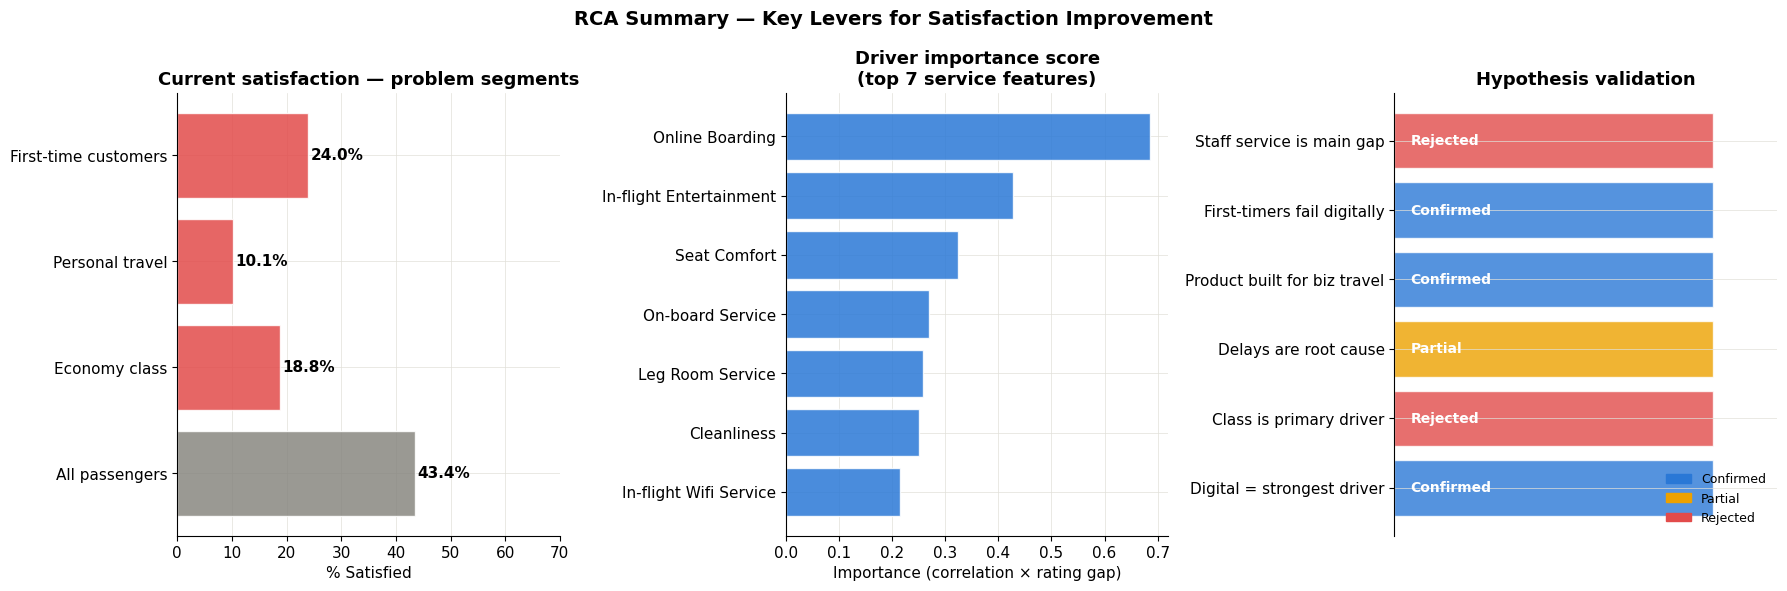

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('RCA Summary — Key Levers for Satisfaction Improvement', fontsize=14, fontweight='bold')

# ── 9a — Current satisfaction by high-impact segment (computed dynamically) ───
ax = axes[0]
seg_rates = {
    'All passengers':     df['sat_binary'].mean() * 100,
    'Economy class':      df[df['Class']=='Economy']['sat_binary'].mean() * 100,
    'Personal travel':    df[df['Type of Travel']=='Personal']['sat_binary'].mean() * 100,
    'First-time customers': df[df['Customer Type']=='First-time']['sat_binary'].mean() * 100,
}
segments = list(seg_rates.keys())
rates    = list(seg_rates.values())
cols     = [GRAY, RED, RED, RED]
ax.barh(segments, rates, color=cols, alpha=0.85, edgecolor='white')
ax.set_xlabel('% Satisfied')
ax.set_title('Current satisfaction — problem segments')
for i, v in enumerate(rates):
    ax.text(v+0.5, i, f'{v:.1f}%', va='center', fontsize=11, fontweight='bold')
ax.set_xlim(0, 70)
ax.xaxis.grid(True); ax.set_axisbelow(True)

# ── 9b — Driver importance (correlation × rating gap, computed) ───────────────
ax = axes[1]
corr_series = df[SERVICE_COLS + ['sat_binary']].corr()['sat_binary'].drop('sat_binary')
avg_by_sat  = df.groupby('Satisfaction')[SERVICE_COLS].mean()
gap_series  = avg_by_sat.loc['Satisfied'] - avg_by_sat.loc['Neutral or Dissatisfied']
importance_series = (corr_series * gap_series).sort_values()

# Show top 7 by importance
top7_imp = importance_series.nlargest(7).sort_values()
bar_c = [BLUE if v > importance_series.median() else AMBER for v in top7_imp]
ax.barh(top7_imp.index, top7_imp.values, color=bar_c, alpha=0.85, edgecolor='white')
ax.set_xlabel('Importance (correlation × rating gap)')
ax.set_title('Driver importance score\n(top 7 service features)')
ax.xaxis.grid(True); ax.set_axisbelow(True)

# ── 9c — Hypothesis validation summary ───────────────────────────────────────
ax = axes[2]
hypotheses = [
    'Digital = strongest driver',
    'Class is primary driver',
    'Delays are root cause',
    'Product built for biz travel',
    'First-timers fail digitally',
    'Staff service is main gap',
]
verdicts = [1, 0, 0.5, 1, 1, 0]
colors_h = [BLUE if v==1 else RED if v==0 else AMBER for v in verdicts]
labels_h = ['Confirmed' if v==1 else 'Rejected' if v==0 else 'Partial' for v in verdicts]
ax.barh(hypotheses, [1]*len(hypotheses), color=colors_h, alpha=0.8, edgecolor='white')
for i, (lbl, col) in enumerate(zip(labels_h, colors_h)):
    ax.text(0.05, i, lbl, va='center', fontsize=10, fontweight='bold', color='white')
ax.set_xlim(0, 1.2)
ax.set_xticks([])
ax.set_title('Hypothesis validation')
ax.spines['bottom'].set_visible(False)
ax.legend(handles=[
    mpatches.Patch(color=BLUE,  label='Confirmed'),
    mpatches.Patch(color=AMBER, label='Partial'),
    mpatches.Patch(color=RED,   label='Rejected'),
], fontsize=9, frameon=False, loc='lower right')

plt.tight_layout()
save_fig(fig, 'fig_07_rca_summary.png')
plt.show()


In [16]:
# Driver importance table — fully computed, no hardcoded values
corr_series = df[SERVICE_COLS + ['sat_binary']].corr()['sat_binary'].drop('sat_binary')
avg_by_sat  = df.groupby('Satisfaction')[SERVICE_COLS].mean()
gap_series  = avg_by_sat.loc['Satisfied'] - avg_by_sat.loc['Neutral or Dissatisfied']

importance = pd.DataFrame({
    'Pearson_r':   corr_series,
    'Rating_gap':  gap_series,
    'Importance':  corr_series * gap_series
}).sort_values('Importance', ascending=False)

print("=== Driver Importance (correlation × rating gap) ===")
display(importance.round(4))


=== Driver Importance (correlation × rating gap) ===


,Pearson_r,Rating_gap,Importance
Online Boarding,0.5017,1.3672,0.6860
In-flight Entertainment,0.3982,1.0718,0.4268
Seat Comfort,0.3488,0.9284,0.3239
On-board Service,0.3222,0.8366,0.2696
Leg Room Service,0.3124,0.8296,0.2592
Cleanliness,0.3070,0.8137,0.2498
In-flight Wifi Service,0.2835,0.7602,0.2155
Baggage Handling,0.2487,0.5920,0.1472
Check-in Service,0.2373,0.6060,0.1438
In-flight Service,0.2449,0.5814,0.1424


In [17]:
# Close the multi-page PDF — run this cell last
pdf_pages.close()
print(f"All figures saved to: {PDF_PATH}")
print("Individual PNGs saved as:")
for name in [
    'fig_01_satisfaction_distribution.png',
    'fig_02_segment_profiles.png',
    'fig_03_operational_metrics.png',
    'fig_04_service_ratings.png',
    'fig_05_correlation_matrix.png',
    'fig_06_segment_deepdives.png',
    'fig_07_rca_summary.png',
]:
    print(f"  {name}")


All figures saved to: airline_satisfaction_eda_figures.pdf
Individual PNGs saved as:
  fig_01_satisfaction_distribution.png
  fig_02_segment_profiles.png
  fig_03_operational_metrics.png
  fig_04_service_ratings.png
  fig_05_correlation_matrix.png
  fig_06_segment_deepdives.png
  fig_07_rca_summary.png


---
## 10. Key Findings & Recommendations

### Root Causes (structured 5-Why)

| # | Root Cause | Evidence | Priority |
|---|-----------|----------|:--------:|
| RC-1 | **Digital infrastructure underinvestment** — online boarding UX + Wi-Fi | Online boarding r=0.502 (top driver); Wi-Fi 54% low ratings | **P0** |
| RC-2 | **Product-market fit gap for personal travelers** | 10.1% satisfaction even in business class for personal travel | **P1** |
| RC-3 | **Broken first-time customer onboarding** | 76% first-timers dissatisfied; lowest scores on digital touchpoints | **P1** |

---

### Recommendations

| Action | Impact | Effort |
|--------|--------|:------:|
| Overhaul online boarding UX | High — r=0.50, broadest reach | Medium |
| Upgrade in-flight Wi-Fi infrastructure | High — 54% low ratings, all segments | High (CapEx) |
| Build first-flight guided app onboarding | Medium — product fix, not infra | Low |
| Define personal travel product strategy | High long-term | Strategic |

### Don't invest first in
- Food & drink, gate location, time convenience — weakest correlations
- Staff service (in-flight, check-in) — already lower pain-point scores

### Hypotheses rejected by data
- ❌ Class is the primary driver (personal biz-class ≈88% dissatisfied)
- ❌ Delays are a root cause (only ~4 min gap, small effect)
- ❌ Staff service is the main gap (lowest low-rating %)

### Next steps
1. Train classification model (XGBoost) + SHAP for model-based feature importance
2. Segment-specific models for personal vs business travel (validate RC-2)
3. A/B test design for online boarding UX improvement
